In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer    
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier   

import matplotlib.pyplot as plt 

In [4]:
def apply_mappings(df): 
    df = df.copy()
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7} 
    df['loan_grade'] = df['loan_grade'].map(grade_map)
    df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
    return df


In [5]:
df = pd.read_csv('credit_risk_dataset.csv')
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
categorical_cols = ['person_home_ownership', 'loan_intent']
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

In [8]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))   
    ]), categorical_cols),
])

In [9]:
logistic_pipeline = Pipeline([
    ('mapper', FunctionTransformer(apply_mappings)),
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

logistic_pipeline.fit(X_train, y_train)
y_pred_proba_lr = logistic_pipeline.predict_proba(X_test)[:, 1]


In [10]:
xgb_pipeline = Pipeline([
    ('mapper', FunctionTransformer(apply_mappings)),
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(learning_rate = 0.1, max_depth = 4, n_estimators = 300, eval_metric='logloss', random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]


In [11]:
roc_auc_lr  = roc_auc_score(y_test, y_pred_proba_lr)
roc_auc_xgb  = roc_auc_score(y_test, y_pred_proba_xgb)
precision_lr = precision_score(y_test, (y_pred_proba_lr >= 0.5).astype(int))
precision_xgb = precision_score(y_test, (y_pred_proba_xgb >= 0.5).astype(int))
recall_lr = recall_score(y_test, (y_pred_proba_lr >= 0.5).astype(int))
recall_xgb = recall_score(y_test, (y_pred_proba_xgb >= 0.5).astype(int))
f1_lr = f1_score(y_test, (y_pred_proba_lr >= 0.5).astype(int))
f1_xgb = f1_score(y_test, (y_pred_proba_xgb >= 0.5).astype(int))  

In [12]:
print(f'Logistic Regression ROC AUC: {roc_auc_lr:.2f}')
print(f'XGBoost ROC AUC: {roc_auc_xgb:.2f}')    

print(f'Logistic Regression Precision: {precision_lr:.2f}')
print(f'XGBoost Precision: {precision_xgb:.2f}')

print(f'Logistic Regression Recall: {recall_lr:.2f}')
print(f'XGBoost Recall: {recall_xgb:.2f}')

print(f'Logistic Regression F1 Score: {f1_lr:.2f}')
print(f'XGBoost F1 Score: {f1_xgb:.2f}')


Logistic Regression ROC AUC: 0.87
XGBoost ROC AUC: 0.95
Logistic Regression Precision: 0.75
XGBoost Precision: 0.97
Logistic Regression Recall: 0.52
XGBoost Recall: 0.73
Logistic Regression F1 Score: 0.61
XGBoost F1 Score: 0.83


In [13]:
results = pd.DataFrame(y_pred_proba_xgb, columns=['pd'])
print(f'Portfolio Default Probability (PD): {results["pd"].mean()*100:.2f}%')

results['ead'] = X_test['loan_amnt'].values
print(f'Average EAD: ${results["ead"].mean():.2f}')

lgd_map = {'A': 0.25, 'B': 0.35, 'C': 0.45, 'D': 0.55, 'E': 0.65, 'F': 0.75, 'G': 0.85}
results['loan_grade'] = X_test['loan_grade'].values
results['lgd'] = results['loan_grade'].map(lgd_map)

results['el'] = results['pd'] * results['ead'] * results['lgd']
print(f'Total Expected Loss: ${results["el"].sum():,.2f}')
print(f'Average Expected Loss: ${results["el"].mean():.2f}')

loss_contribution = (results.groupby('loan_grade')['el'].sum() / results['el'].sum()).sort_values(ascending=False)
print('\nLoss Contribution by Loan Grade (%):')
print((loss_contribution * 100).round(2))

Portfolio Default Probability (PD): 21.68%
Average EAD: $9670.39
Total Expected Loss: $7,351,864.07
Average Expected Loss: $1128.11

Loss Contribution by Loan Grade (%):
loan_grade
D    37.93
B    17.77
C    15.57
E    13.08
A     6.22
F     5.06
G     4.38
Name: el, dtype: float64


In [14]:
def scenario_analysis(results, scenarios): 
    scenario_results = {} 

    for name, (pd_mult, lgd_add) in scenarios.items():
        scenario_df = results.copy()    
        scenario_df['pd_scenario'] = scenario_df['pd'] * pd_mult
        scenario_df['lgd_scenario'] = (scenario_df['lgd'] + lgd_add).clip(upper=1.0)    
        scenario_df['el_scenario'] = scenario_df['pd_scenario'] * scenario_df['ead'] * scenario_df['lgd_scenario']
        scenario_results[name] = scenario_df['el_scenario'].sum() 

    return pd.DataFrame.from_dict(scenario_results, orient = 'index', columns=['el'])

scenarios = {
    'Baseline': (1.0, 0.0), 
    'Mild Stress': (1.2, 0.05), 
    'Moderate Stress': (1.5, 0.1),  
    'Heavy Stress': (2.0, 0.2)  
}
    
scenario_results = scenario_analysis(results, scenarios)
print('\nScenario Analysis - Total Expected Loss:')
print(scenario_results.applymap(lambda x: f'${x:,.2f}'))   

results['el_stress'] = (
    results['pd'] * 1.5 *
    results['ead'] *
    (results['lgd'] + 0.1).clip(upper=1.0)
)


Scenario Analysis - Total Expected Loss:
                             el
Baseline          $7,351,864.07
Mild Stress       $9,753,931.23
Moderate Stress  $13,357,030.97
Heavy Stress     $20,877,152.45


/var/folders/3s/r8gqdd0d04xdvr0f7g1hb2r00000gn/T/ipykernel_28221/2869982446.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(scenario_results.applymap(lambda x: f'${x:,.2f}'))


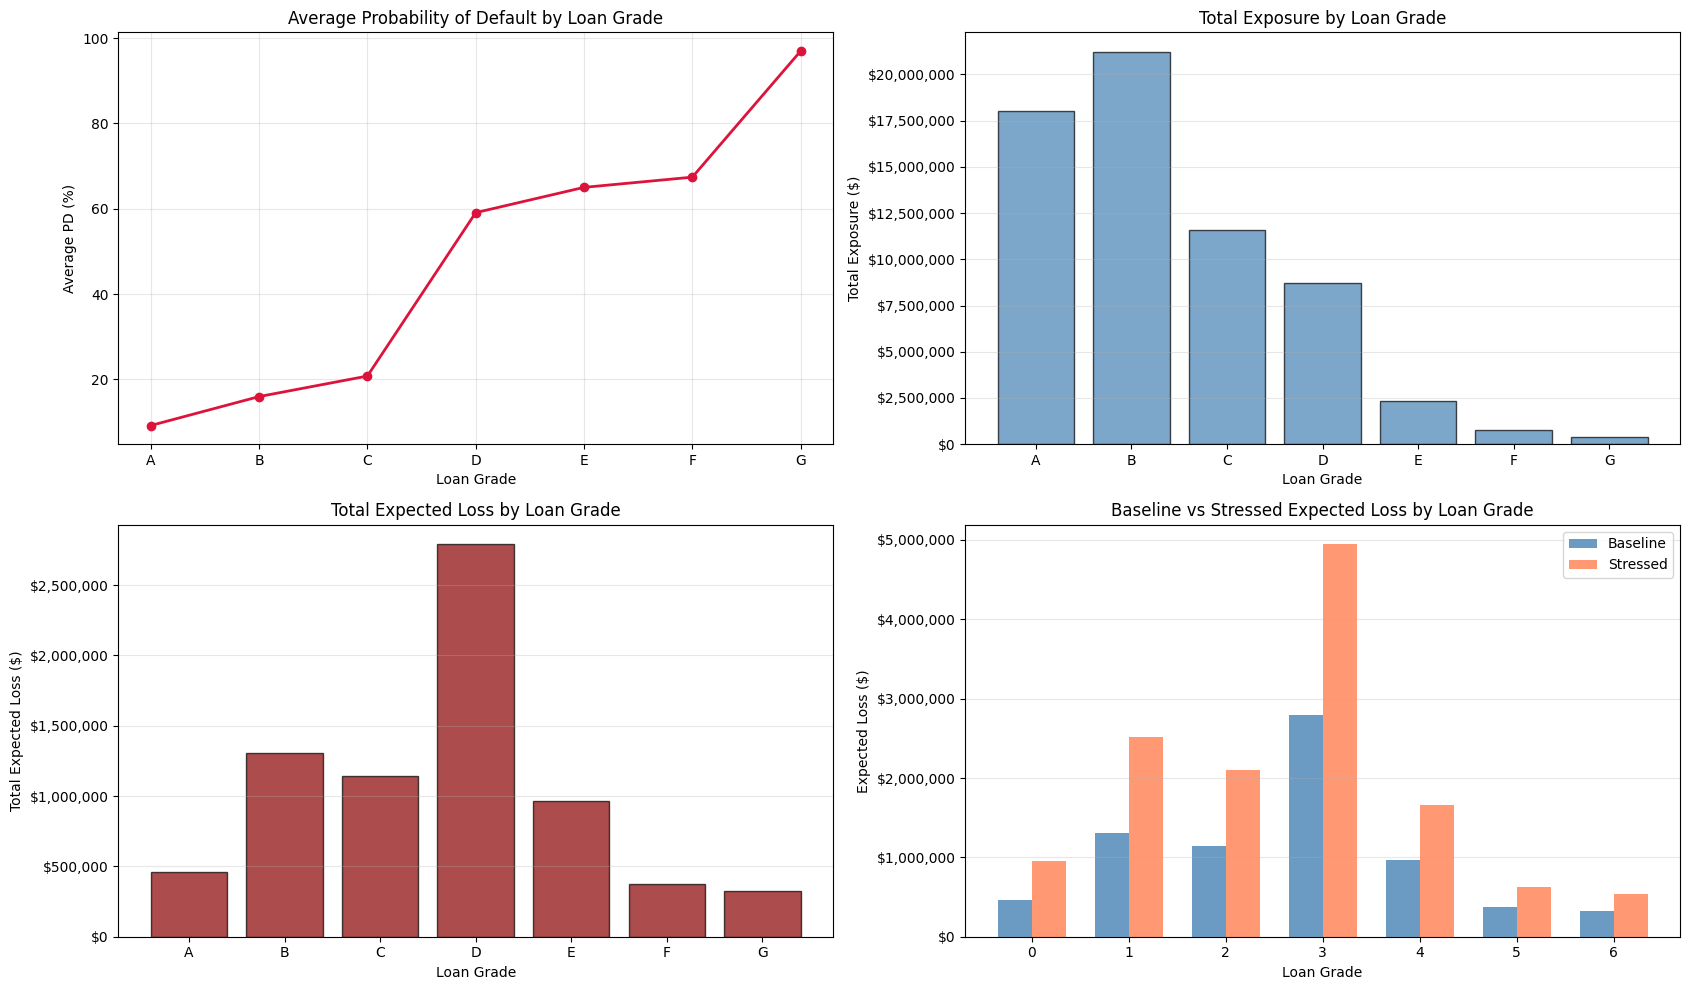

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

grade_pd = results.groupby('loan_grade')['pd'].mean()
axes[0, 0].plot(grade_pd.index, grade_pd.values * 100, 
                marker='o', linewidth=2, markersize=6, color='crimson')
axes[0, 0].set_title('Average Probability of Default by Loan Grade')
axes[0, 0].set_xlabel('Loan Grade')
axes[0, 0].set_ylabel('Average PD (%)')
axes[0, 0].grid(True, alpha=0.3)

grade_exp = results.groupby('loan_grade')['ead'].sum()
axes[0, 1].bar(grade_exp.index, grade_exp.values, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0, 1].set_title('Total Exposure by Loan Grade')
axes[0, 1].set_xlabel('Loan Grade')
axes[0, 1].set_ylabel('Total Exposure ($)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

grade_el = results.groupby('loan_grade')['el'].sum()
axes[1, 0].bar(grade_el.index, grade_el.values, alpha=0.7, color='darkred', edgecolor='black')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1, 0].set_title('Total Expected Loss by Loan Grade')
axes[1, 0].set_xlabel('Loan Grade')
axes[1, 0].set_ylabel('Total Expected Loss ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

baseline_el = results.groupby('loan_grade')['el'].sum()
stressed_el = results.groupby('loan_grade')['el_stress'].sum()
x = np.arange(len(baseline_el.index))
width = 0.35
axes[1, 1].bar(x - width/2, baseline_el.values, width, label='Baseline', color='steelblue', alpha=0.8)
axes[1, 1].bar(x + width/2, stressed_el.values, width, label='Stressed', color='coral', alpha=0.8)
axes[1, 1].set_title('Baseline vs Stressed Expected Loss by Loan Grade')
axes[1, 1].set_xlabel('Loan Grade')
axes[1, 1].set_ylabel('Expected Loss ($)')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()